In [1]:
# ── Importaciones ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Configuración de visualización
plt.style.use('dark_background')
sns.set_palette('husl')

print('✅ Librerías cargadas correctamente')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ Librerías cargadas correctamente
NumPy: 2.4.2 | Pandas: 2.3.3


In [2]:
# ── Generación de datos sintéticos ──────────────────────────────────────────
np.random.seed(42)  # Reproducibilidad
n = 1000

data = {
    'login_hour':       np.random.randint(0, 24, n),
    'location':         np.random.choice(['CR', 'US', 'MX', 'ES'], n, p=[0.6, 0.2, 0.1, 0.1]),
    'failed_attempts':  np.random.randint(0, 5, n),
    'access_count':     np.random.randint(1, 20, n),
    'activity_type':    np.random.choice(['login', 'download', 'upload', 'delete'], n,
                                          p=[0.5, 0.25, 0.15, 0.1]),
    'device_type':      np.random.choice(['desktop', 'mobile', 'tablet'], n, p=[0.6, 0.3, 0.1]),
    'session_duration': np.random.randint(1, 120, n),
    'day_of_week':      np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], n)
}

df = pd.DataFrame(data)

# Guardar datos crudos
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/user_behavior.csv', index=False)

print(f'Dataset generado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head(10)

Dataset generado: 1000 registros, 8 columnas


,login_hour,location,failed_attempts,access_count,activity_type,device_type,session_duration,day_of_week
0,6,CR,4,17,upload,tablet,21,Thu
1,19,US,1,9,upload,desktop,99,Mon
2,14,CR,4,14,download,tablet,105,Mon
3,10,CR,1,12,login,desktop,40,Wed
4,7,CR,3,6,download,mobile,67,Fri
5,20,CR,0,17,download,desktop,25,Wed
6,6,CR,3,19,download,desktop,109,Mon
7,18,CR,4,19,login,desktop,102,Sun
8,22,CR,3,16,login,mobile,109,Sun
9,10,CR,3,12,upload,desktop,55,Sun


In [3]:
# ── Análisis exploratorio básico ─────────────────────────────────────────────
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
print(df.describe().round(2))

print('\n=== VALORES FALTANTES ===')
print(df.isnull().sum())

print('\n=== DISTRIBUCIÓN DE CATEGORÍAS ===')
for col in ['location', 'activity_type', 'device_type', 'day_of_week']:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== ESTADÍSTICAS DESCRIPTIVAS ===
       login_hour  failed_attempts  access_count  session_duration
count     1000.00          1000.00       1000.00           1000.00
mean        11.43             2.09         10.16             60.40
std          7.15             1.42          5.55             33.72
min          0.00             0.00          1.00              1.00
25%          5.00             1.00          5.00             32.00
50%         12.00             2.00         10.00             61.00
75%         18.00             3.00         15.00             88.25
max         23.00             4.00         19.00            119.00

=== VALORES FALTANTES ===
login_hour          0
location            0
failed_attempts     0
access_count        0
activity_type       0
device_type         0
session_duration    0
day_of_week         0
dtype: int64

=== DISTRIBUCIÓN DE CATEGORÍAS ===

location:
location
CR    585
US    208
MX    108
ES     99
Name: count, dtype: int64

activity_type:
activity_

In [4]:
# ── Encoding de variables categóricas ───────────────────────────────────────
# LabelEncoder ordena alfabéticamente, así que documentamos el mapeo exacto

le = LabelEncoder()
df_model = df.copy()

# Aplicar encoding y documentar cada mapeo
categorical_cols = ['location', 'activity_type', 'device_type', 'day_of_week']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {mapping}')

print('\n=== Dataset después del encoding ===')
print(df_model.dtypes)
df_model.head()

location: {'CR': np.int64(0), 'ES': np.int64(1), 'MX': np.int64(2), 'US': np.int64(3)}
activity_type: {'delete': np.int64(0), 'download': np.int64(1), 'login': np.int64(2), 'upload': np.int64(3)}
device_type: {'desktop': np.int64(0), 'mobile': np.int64(1), 'tablet': np.int64(2)}
day_of_week: {'Fri': np.int64(0), 'Mon': np.int64(1), 'Sat': np.int64(2), 'Sun': np.int64(3), 'Thu': np.int64(4), 'Tue': np.int64(5), 'Wed': np.int64(6)}

=== Dataset después del encoding ===
login_hour          int32
location            int64
failed_attempts     int32
access_count        int32
activity_type       int64
device_type         int64
session_duration    int32
day_of_week         int64
dtype: object


,login_hour,location,failed_attempts,access_count,activity_type,device_type,session_duration,day_of_week
0,6,0,4,17,3,2,21,4
1,19,3,1,9,3,0,99,1
2,14,0,4,14,1,2,105,1
3,10,0,1,12,2,0,40,6
4,7,0,3,6,1,1,67,0


In [5]:
# ── Entrenamiento ────────────────────────────────────────────────────────────
model = IsolationForest(
    contamination=0.05,  # 5% de anomalías esperadas
    n_estimators=100,
    random_state=42,
    n_jobs=-1            # Usar todos los cores disponibles
)

model.fit(df_model)

# Predicciones: -1 = anómalo, 1 = normal
predictions = model.predict(df_model)

# Score continuo: valores más negativos = más anómalos
anomaly_scores = model.decision_function(df_model)

df_model['anomaly']       = predictions
df_model['anomaly_score'] = anomaly_scores

print('=== RESULTADOS DEL MODELO ===')
print(df_model['anomaly'].value_counts())
print(f'\nAnomalías detectadas: {(predictions == -1).sum()} ({(predictions == -1).mean()*100:.1f}%)')
print(f'Comportamiento normal: {(predictions == 1).sum()} ({(predictions == 1).mean()*100:.1f}%)')

=== RESULTADOS DEL MODELO ===
anomaly
 1    950
-1     50
Name: count, dtype: int64

Anomalías detectadas: 50 (5.0%)
Comportamiento normal: 950 (95.0%)


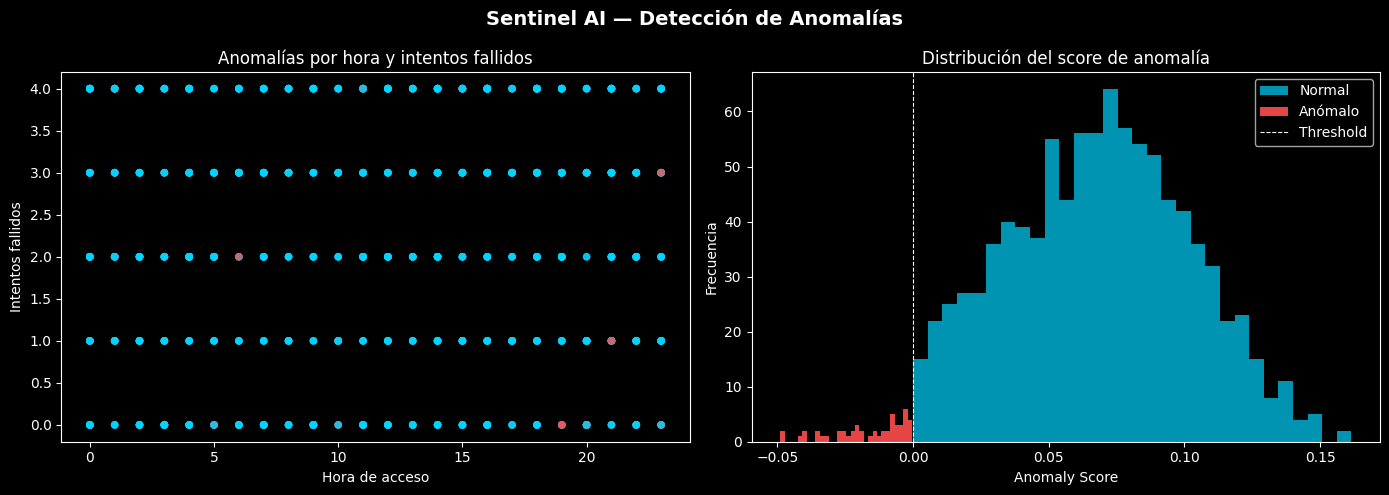

Azul = comportamiento normal | Rojo = anomalía detectada


In [6]:
# ── Visualización: Hora vs Intentos fallidos ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentinel AI — Detección de Anomalías', fontsize=14, fontweight='bold', color='white')

# Scatter: Hora vs Intentos fallidos
colors = ['#FF4D4D' if a == -1 else '#00D4FF44' for a in predictions]
axes[0].scatter(df_model['login_hour'], df_model['failed_attempts'],
                c=colors, s=20, alpha=0.7)
axes[0].set_xlabel('Hora de acceso')
axes[0].set_ylabel('Intentos fallidos')
axes[0].set_title('Anomalías por hora y intentos fallidos')

# Distribución del score de anomalía
axes[1].hist(anomaly_scores[predictions == 1],  bins=30, color='#00D4FF', alpha=0.7, label='Normal')
axes[1].hist(anomaly_scores[predictions == -1], bins=30, color='#FF4D4D', alpha=0.9, label='Anómalo')
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=0.8, label='Threshold')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del score de anomalía')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Azul = comportamiento normal | Rojo = anomalía detectada')

In [7]:
# ── Análisis de anomalías detectadas ────────────────────────────────────────
anomalies = df[predictions == -1].copy()
anomalies['anomaly_score'] = anomaly_scores[predictions == -1]

print(f'Total anomalías: {len(anomalies)}')
print('\n=== Características de los comportamientos anómalos ===')
print(anomalies[['login_hour','failed_attempts','access_count','session_duration']].describe().round(2))

print('\n=== Top 10 registros más anómalos ===')
anomalies.sort_values('anomaly_score').head(10)

Total anomalías: 50

=== Características de los comportamientos anómalos ===
       login_hour  failed_attempts  access_count  session_duration
count       50.00            50.00         50.00             50.00
mean        12.68             1.94         10.18             50.38
std          9.12             1.58          6.87             42.57
min          0.00             0.00          1.00              1.00
25%          3.00             0.25          3.25              8.50
50%         16.00             2.00         10.50             36.50
75%         21.75             3.75         17.00             92.50
max         23.00             4.00         19.00            118.00

=== Top 10 registros más anómalos ===


,login_hour,location,failed_attempts,access_count,activity_type,device_type,session_duration,day_of_week,anomaly_score
436,18,US,4,3,download,tablet,4,Tue,-0.048951
643,6,US,2,1,download,tablet,1,Fri,-0.048929
784,17,US,4,19,download,tablet,97,Fri,-0.040993
69,3,US,4,4,delete,tablet,68,Wed,-0.040827
113,6,ES,1,2,delete,tablet,86,Fri,-0.040809
371,1,US,3,18,delete,desktop,118,Wed,-0.035581
248,0,US,4,12,delete,mobile,3,Wed,-0.034558
814,23,US,0,15,download,tablet,69,Mon,-0.032806
466,4,MX,3,19,login,tablet,1,Fri,-0.031581
712,19,MX,0,16,upload,tablet,71,Tue,-0.027741


In [8]:
# ── Guardar modelo y datos procesados ───────────────────────────────────────
os.makedirs('../model', exist_ok=True)

# Guardar el modelo entrenado
joblib.dump(model, '../model/anomaly_model.pkl')
print('✅ Modelo guardado en: model/anomaly_model.pkl')

# Guardar datos procesados (con columna anomaly, SIN anomaly_score para la app)
df_to_save = df_model.drop(columns=['anomaly_score'])
df_to_save.to_csv('../data/processed_data.csv', index=False)
print('✅ Datos guardados en: data/processed_data.csv')

# Verificar que el modelo funciona
test_input = [[14, 0, 1, 5, 2, 0, 30, 0]]  # Comportamiento normal
test_pred  = model.predict(test_input)
test_score = model.decision_function(test_input)[0]
print(f'\n✅ Test de verificación:')
print(f'   Predicción: {"Normal" if test_pred[0] == 1 else "Anómalo"}')
print(f'   Score: {test_score:.4f}')

✅ Modelo guardado en: model/anomaly_model.pkl
✅ Datos guardados en: data/processed_data.csv

✅ Test de verificación:
   Predicción: Normal
   Score: 0.1104


c:\Users\Admini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Admini\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
